In [16]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Path to the dataset folder
base_dir = '/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast'

# Parse all image paths and extract metadata from the directory hierarchy
all_images = glob.glob(os.path.join(base_dir, '**/*.png'), recursive=True)

data_list = []
for path in all_images:
    parts = path.split(os.sep)
    filename = parts[-1]
    magnification = parts[-2]
    patient_id = parts[-3]
    subtype = parts[-4]
    main_class = parts[-6] 
    
    data_list.append({
        'ImagePath': path,
        'Filename': filename,
        'Class': main_class,
        'Subtype': subtype,
        'Magnification': magnification,
        'PatientID': patient_id
    })

df = pd.DataFrame(data_list)
print(f"Total raw images parsed: {len(df)}")

Total raw images parsed: 7909


In [17]:
# Find all PNG files recursively
all_images = glob.glob(os.path.join(base_dir, '**/*.png'), recursive=True)

data_list = []
for path in all_images:
    # Example path split: ['...', 'benign', 'SOB', 'adenosis', 'SOB_B_A_14-22549AB', '100X', 'filename.png']
    parts = path.split(os.sep)
    
    filename = parts[-1]
    magnification = parts[-2]
    patient_id = parts[-3]
    subtype = parts[-4]
    main_class = parts[-6]  # 'benign' or 'malignant'
    
    data_list.append({
        'ImagePath': path,
        'Filename': filename,
        'Class': main_class,
        'Subtype': subtype,
        'Magnification': magnification,
        'PatientID': patient_id
    })

# Create the master dataframe
df = pd.DataFrame(data_list)
print(f"Total images found: {len(df)}")
df.head(-5)

Total images found: 7909


,ImagePath,Filename,Class,Subtype,Magnification,PatientID
0,/kaggle/input/datasets/ambarish/breakhis/BreaK...,SOB_B_A-14-29960CD-200-012.png,benign,adenosis,200X,SOB_B_A_14-29960CD
1,/kaggle/input/datasets/ambarish/breakhis/BreaK...,SOB_B_A-14-29960CD-200-009.png,benign,adenosis,200X,SOB_B_A_14-29960CD
2,/kaggle/input/datasets/ambarish/breakhis/BreaK...,SOB_B_A-14-29960CD-200-006.png,benign,adenosis,200X,SOB_B_A_14-29960CD
3,/kaggle/input/datasets/ambarish/breakhis/BreaK...,SOB_B_A-14-29960CD-200-011.png,benign,adenosis,200X,SOB_B_A_14-29960CD
4,/kaggle/input/datasets/ambarish/breakhis/BreaK...,SOB_B_A-14-29960CD-200-004.png,benign,adenosis,200X,SOB_B_A_14-29960CD
...,...,...,...,...,...,...
7899,/kaggle/input/datasets/ambarish/breakhis/BreaK...,SOB_M_PC-14-15704-100-012.png,malignant,papillary_carcinoma,100X,SOB_M_PC_14-15704
7900,/kaggle/input/datasets/ambarish/breakhis/BreaK...,SOB_M_PC-14-15704-100-002.png,malignant,papillary_carcinoma,100X,SOB_M_PC_14-15704
7901,/kaggle/input/datasets/ambarish/breakhis/BreaK...,SOB_M_PC-14-15704-100-014.png,malignant,papillary_carcinoma,100X,SOB_M_PC_14-15704
7902,/kaggle/input/datasets/ambarish/breakhis/BreaK...,SOB_M_PC-14-15704-100-024.png,malignant,papillary_carcinoma,100X,SOB_M_PC_14-15704


In [18]:
# 1. Get unique patient IDs mapped to their class
unique_patients = df.groupby('PatientID')['Class'].first().reset_index()

# 2. First split: 80% Train + Val, 20% Test
train_val_patients, test_patients = train_test_split(
    unique_patients['PatientID'], 
    test_size=0.2, 
    stratify=unique_patients['Class'], 
    random_state=42
)

# 3. Second split: Break down the 80% into 65% Train, 15% Val
train_patients, val_patients = train_test_split(
    train_val_patients, 
    test_size=0.2, 
    stratify=unique_patients[unique_patients['PatientID'].isin(train_val_patients)]['Class'], 
    random_state=42
)

# 4. Map back to create image-level DataFrames
train_df = df[df['PatientID'].isin(train_patients)].copy()
val_df = df[df['PatientID'].isin(val_patients)].copy()
test_df = df[df['PatientID'].isin(test_patients)].copy()

# 5. Convert text labels ('benign', 'malignant') into numbers (0, 1)
label_map = {'benign': 0, 'malignant': 1}
train_df['Label'] = train_df['Class'].map(label_map)
val_df['Label'] = val_df['Class'].map(label_map)
test_df['Label'] = test_df['Class'].map(label_map)

print(f"Before Resampling -> Train Images: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Before Resampling -> Train Images: 4993, Val: 1161, Test: 1755


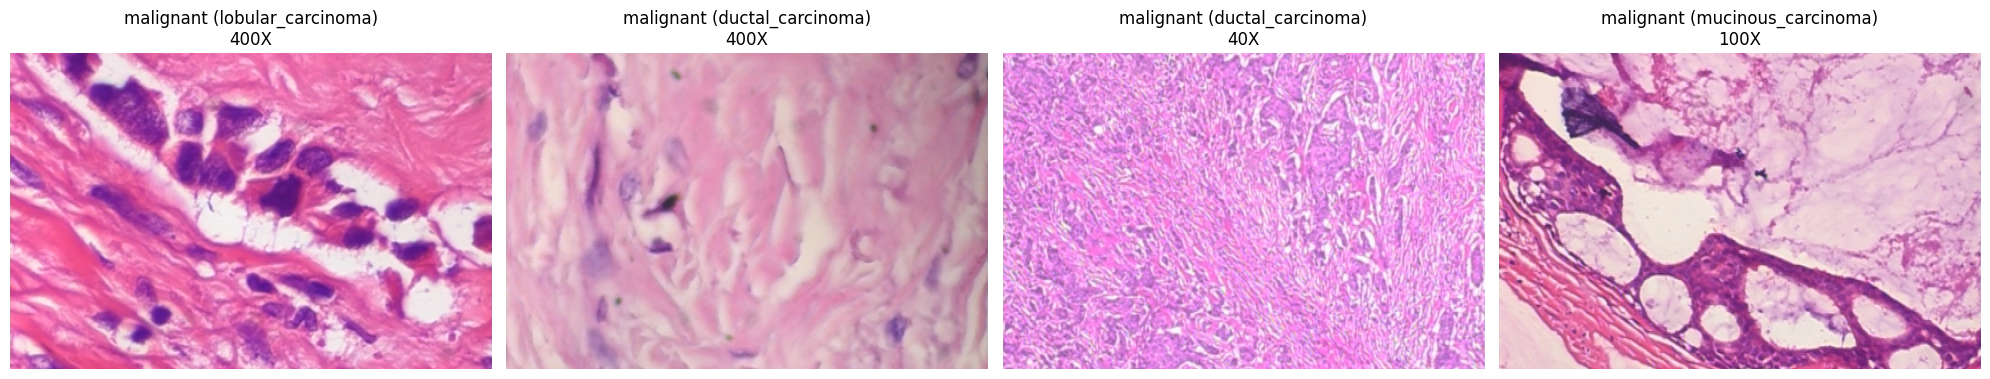

In [19]:
sample_df = df.sample(4, random_state=42)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, (_, row) in enumerate(sample_df.iterrows()):
    img = plt.imread(row['ImagePath'])
    axes[i].imshow(img)
    axes[i].set_title(f"{row['Class']} ({row['Subtype']})\n{row['Magnification']}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# # Calculate the maximum count among the classes in the training set
# max_count = np.max(train_df['Label'].value_counts())

# # Resample the training dataframe to balance classes perfectly
# train_df = train_df.groupby('Label').sample(n=max_count, replace=True).reset_index(drop=True)

# print("--- Balanced Training Class Distribution After Resampling ---")
# print(train_df['Class'].value_counts())
# print(f"Total Train Images now: {len(train_df)}")

In [20]:
# Native input size for EfficientNetB5
# IMG_SIZE = (456, 456)
IMG_SIZE = (224, 224)

BATCH_SIZE = 16 

def parse_image(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)  # EfficientNet scales internally, no manual division by 255
    return img, label

def create_tf_dataset(dataframe, shuffle=False):
    paths = dataframe['ImagePath'].values
    labels = dataframe['Label'].values
    
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)
        
    return dataset.batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

train_ds = create_tf_dataset(train_df, shuffle=True)
val_ds = create_tf_dataset(val_df, shuffle=False)
test_ds = create_tf_dataset(test_df, shuffle=False)

In [21]:
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['Label']),
    y=train_df['Label'].values
)

class_weights = {i: weights[i] for i in range(len(weights))}

print("Generated Class Weights:", class_weights)

Generated Class Weights: {0: np.float64(1.7052595628415301), 1: np.float64(0.7074241994899405)}


In [22]:
from tensorflow.keras import layers, models

base_model_2 = tf.keras.applications.DenseNet121(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model_2.trainable = False  # Freeze the backbone architecture for baseline

inputs = layers.Input(shape=(224, 224, 3))
x = base_model_2(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model_2 = models.Model(inputs, outputs)

model_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model_2.summary()

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.7, patience=5, min_lr=1e-6, verbose=1)
]

EPOCHS = 20
history = model_2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights
)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 76s 159ms/step - accuracy: 0.8153 - auc: 0.8697 - loss: 1.0426 - val_accuracy: 0.7554 - val_auc: 0.7414 - val_loss: 1.1246 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 69ms/step - accuracy: 0.8528 - auc: 0.9036 - loss: 0.8471 - val_accuracy: 0.7984 - val_auc: 0.7766 - val_loss: 0.8350 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 69ms/step - accuracy: 0.8568 - auc: 0.9162 - loss: 0.6452 - val_accuracy: 0.7778 - val_auc: 0.7623 - val_loss: 0.8675 - learning_rate: 0.0010
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.8782 - auc: 0.9330 - loss: 0.5198 - val_accuracy: 0.7795 - val_auc: 0.8002 - val_loss: 0.7886 - learning_rate: 0.0010
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.8734 - auc: 0.9275 - loss: 0.5936 - val_accuracy: 0.8165 - val_auc: 0.8502 - val_loss: 0.5004 - learning_rate: 0.0010
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.8

In [23]:
history2 = model_2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    initial_epoch=13,  # Tells Keras to start counting from epoch 20 (displayed as Epoch 21)
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 14/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.8878 - auc: 0.9342 - loss: 0.4726 - val_accuracy: 0.7786 - val_auc: 0.7851 - val_loss: 0.8099 - learning_rate: 7.0000e-04
Epoch 15/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.8780 - auc: 0.9355 - loss: 0.5005 - val_accuracy: 0.8174 - val_auc: 0.8656 - val_loss: 0.4779 - learning_rate: 7.0000e-04
Epoch 16/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 68ms/step - accuracy: 0.8844 - auc: 0.9388 - loss: 0.4179 - val_accuracy: 0.8036 - val_auc: 0.8598 - val_loss: 0.5457 - learning_rate: 7.0000e-04
Epoch 17/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.8840 - auc: 0.9392 - loss: 0.4374 - val_accuracy: 0.7795 - val_auc: 0.8294 - val_loss: 0.6710 - learning_rate: 7.0000e-04
Epoch 18/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.8904 - auc: 0.9418 - loss: 0.4398 - val_accuracy: 0.7898 - val_auc: 0.8264 - val_loss: 0.6254 - learning_rate: 7.0000e-04
Epoch 19/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 

In [24]:
history3 = model_2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    initial_epoch=20,  # Tells Keras to start counting from epoch 20 (displayed as Epoch 21)
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 21/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 68ms/step - accuracy: 0.8826 - auc: 0.9317 - loss: 0.4614 - val_accuracy: 0.7864 - val_auc: 0.8197 - val_loss: 0.6130 - learning_rate: 4.9000e-04
Epoch 22/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 67ms/step - accuracy: 0.8844 - auc: 0.9380 - loss: 0.4240 - val_accuracy: 0.8088 - val_auc: 0.8335 - val_loss: 0.5189 - learning_rate: 4.9000e-04
Epoch 23/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.8943 - auc: 0.9468 - loss: 0.3879 - val_accuracy: 0.8071 - val_auc: 0.8505 - val_loss: 0.5559 - learning_rate: 4.9000e-04
Epoch 24/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.8876 - auc: 0.9371 - loss: 0.4033 - val_accuracy: 0.8131 - val_auc: 0.8525 - val_loss: 0.4946 - learning_rate: 4.9000e-04
Epoch 25/25
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8579 - auc: 0.7669 - loss: 0.5741
Epoch 25: ReduceLROnPlateau reducing learning rate to 0.00034300000406801696.
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0

In [27]:
# Save the model

model_2.save('my_densenet_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
model_2.save_weights('my_densenet_weights.weights.h5')

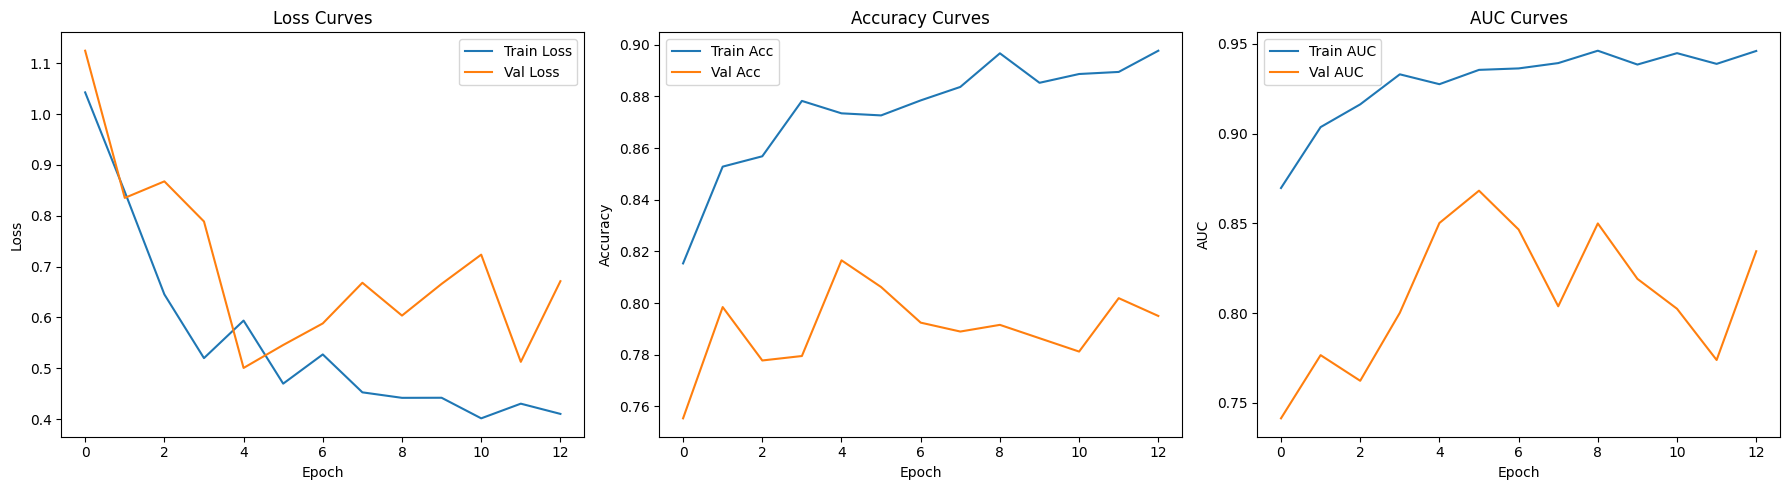

In [28]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Plot Loss
ax[0].plot(history.history['loss'], label='Train Loss')
ax[0].plot(history.history['val_loss'], label='Val Loss')
ax[0].set_title('Loss Curves')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

# Plot Accuracy
ax[1].plot(history.history['accuracy'], label='Train Acc')
ax[1].plot(history.history['val_accuracy'], label='Val Acc')
ax[1].set_title('Accuracy Curves')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()

# Plot AUC
ax[2].plot(history.history['auc'], label='Train AUC')
ax[2].plot(history.history['val_auc'], label='Val AUC')
ax[2].set_title('AUC Curves')
ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('AUC')
ax[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
# from sklearn.metrics import classification_report, confusion_matrix, roc_curve

# print("Generating predictions on the test dataset...")

# # 1. تجميع الإجابات الحقيقية والتوقعات في خطوة واحدة (عشان نضمن التزامن 100%)
# y_true = []
# y_pred_probs = []

# for images, labels in test_ds:
#     preds = model.predict(images, verbose=0)
#     y_pred_probs.extend(preds)
#     y_true.extend(labels.numpy())

# y_true = np.array(y_true)
# y_pred_probs = np.array(y_pred_probs).flatten()

# # 2. حساب أفضل العتبات تلقائياً باستخدام ROC Curve
# fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)

# # حساب الـ Geometric Mean (G-Mean) لكل عتبة لاختيار أفضل توازن طبياً
# gmeans = np.sqrt(tpr * (1 - fpr))
# best_index = np.argmax(gmeans)
# optimal_threshold = thresholds[best_index]

# print(f"\n[INFO] Optimal Threshold calculated automatically: {optimal_threshold:.4f}")

# # 3. تحويل الاحتمالات لأرقام (0 أو 1) بناءً على العتبة المثالية الجديدة
# y_pred = (y_pred_probs > optimal_threshold).astype(int)

# # 4. طباعة التقرير النهائي (Precision, Recall, F1 score)
# print("\n--- Binary Classification Performance Report (Optimized) ---")
# target_labels = ['Benign (0)', 'Malignant (1)']
# print(classification_report(y_true, y_pred, target_names=target_labels))

# # 5. رسم الـ Confusion Matrix المعدلة
# cm = confusion_matrix(y_true, y_pred)
# plt.figure(figsize=(6, 5))
# sns.heatmap(
#     cm, 
#     annot=True, 
#     fmt='d', 
#     cmap='Blues', 
#     xticklabels=['Predicted Benign', 'Predicted Malignant'], 
#     yticklabels=['True Benign', 'True Malignant']
# )
# plt.title(f'BreaKHis Confusion Matrix (Threshold: {optimal_threshold:.2f})')
# plt.tight_layout()
# plt.show()

In [21]:
# import os
# os.makedirs('/kaggle/working/models', exist_ok=True)

# baseline_path = '/kaggle/working/models/breakhis_densenet121_baseline.keras'
# model_2.save(baseline_path)
# print(f"Baseline feature extractor model saved to: {baseline_path}")

Baseline feature extractor model saved to: /kaggle/working/models/breakhis_densenet121_baseline.keras


Fine Tuning

In [ ]:
# finetuned_path = '/kaggle/working/models/breakhis_efficientnetb5_finetuned.keras'
# ft_model.save(finetuned_path)
# print(f"Fine-tuned model saved successfully to: {finetuned_path}")

In [ ]:
# from sklearn.metrics import classification_report, confusion_matrix, roc_curve

# print("Generating predictions on the test dataset...")

# # 1. تجميع الإجابات الحقيقية والتوقعات في خطوة واحدة (عشان نضمن التزامن 100%)
# y_true = []
# y_pred_probs = []

# for images, labels in test_ds:
#     preds = model.predict(images, verbose=0)
#     y_pred_probs.extend(preds)
#     y_true.extend(labels.numpy())

# y_true = np.array(y_true)
# y_pred_probs = np.array(y_pred_probs).flatten()

# # 2. حساب أفضل العتبات تلقائياً باستخدام ROC Curve
# fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)

# # حساب الـ Geometric Mean (G-Mean) لكل عتبة لاختيار أفضل توازن طبياً
# gmeans = np.sqrt(tpr * (1 - fpr))
# best_index = np.argmax(gmeans)
# optimal_threshold = thresholds[best_index]

# print(f"\n[INFO] Optimal Threshold calculated automatically: {optimal_threshold:.4f}")

# # 3. تحويل الاحتمالات لأرقام (0 أو 1) بناءً على العتبة المثالية الجديدة
# y_pred = (y_pred_probs > optimal_threshold).astype(int)

# # 4. طباعة التقرير النهائي (Precision, Recall, F1 score)
# print("\n--- Binary Classification Performance Report (Optimized) ---")
# target_labels = ['Benign (0)', 'Malignant (1)']
# print(classification_report(y_true, y_pred, target_names=target_labels))

# # 5. رسم الـ Confusion Matrix المعدلة
# cm = confusion_matrix(y_true, y_pred)
# plt.figure(figsize=(6, 5))
# sns.heatmap(
#     cm, 
#     annot=True, 
#     fmt='d', 
#     cmap='Blues', 
#     xticklabels=['Predicted Benign', 'Predicted Malignant'], 
#     yticklabels=['True Benign', 'True Malignant']
# )
# plt.title(f'BreaKHis Confusion Matrix (Threshold: {optimal_threshold:.2f})')
# plt.tight_layout()
# plt.show()